In [1]:
!pip -q install -U "transformers==4.46.1" "huggingface_hub==0.25.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.6/436.6 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
diffusers 0.34.0 requires huggingface-hub>=0.27.0, but you have huggingface-hub 0.25.2 which is incompatible.
gradio 5.38.1 requires huggingface-hub>=0.28.1, but you have huggingface-hub 0.25.2 which is incompatible.
gradio 5.38.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.0a1 which is incompatible.


In [2]:
%matplotlib inline
from sklearn.metrics import f1_score, precision_score, recall_score
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import re
import time
from tqdm.auto import tqdm  # Progress bar
from collections import Counter
import csv
import os
import shutil

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, AutoModelForSeq2SeqLM
from sklearn.model_selection import train_test_split, StratifiedKFold
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
for item in os.listdir("/kaggle/working"):
    path = os.path.join("/kaggle/working", item)
    if os.path.isdir(path):
        shutil.rmtree(path)
    else:
        os.remove(path)

In [4]:
# --- Hyperparameter ---
LEARNING_RATE = 5e-6
NUM_EPOCHS = 50
PATIENCE = 3
BATCH_SIZE = 32
NUM_CLASSES = 6
DROPOUT_RATE=0.3

# Pengumpulan Data

In [5]:
df = pd.read_csv('/kaggle/input/dataset-emosi/df_emosi.csv', sep='\t')
df

,Tweet,Label
0,pagi2 udah di buat emosi :),Anger
1,"kok stabilitas negara, memange 10 thn negara t...",Anger
2,dah lah emosi mulu liat emyu,Anger
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",Anger
4,dih lu yg nyebelin bego,Anger
...,...,...
7075,pagi saat seisi semesta sujud pada zat yg acap...,Sad
7076,"meski engkau yg pergi, meski engkau yg meningg...",Sad
7077,udah biasa kalah dan tersakiti,Sad
7078,"apakabar ku?. apakah baik-baik saja,, tidak, a...",Sad


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7080 entries, 0 to 7079
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tweet   7080 non-null   object
 1   Label   7080 non-null   object
dtypes: object(2)
memory usage: 110.8+ KB


In [7]:
df['Label'].value_counts()

Label
Neutral    2001
Joy        1275
Anger      1130
Sad        1003
Fear        911
Love        760
Name: count, dtype: int64

In [8]:
CHART_DIR = "chart_file"
os.makedirs(CHART_DIR, exist_ok=True)

Grafik disimpan ke: chart_file/grafik_batang_distribusi_data.png


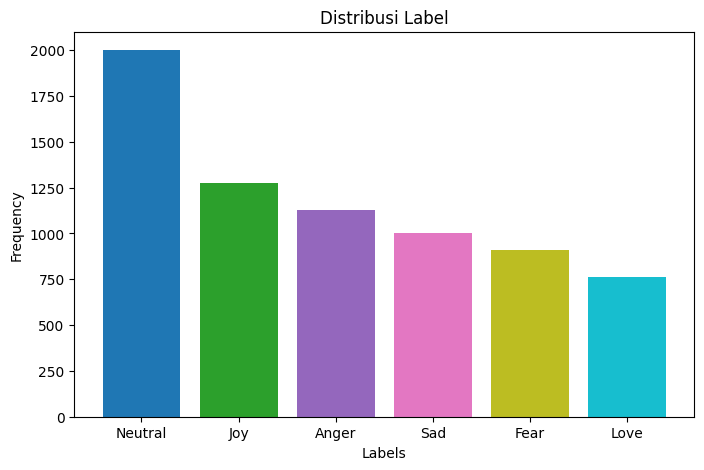

In [9]:
value_counts = df['Label'].value_counts().reset_index()
value_counts.columns = ['Labels', 'Frequency']
colors = plt.cm.tab10(np.linspace(0, 1, len(value_counts)))

plt.figure(figsize=(8, 5))
plt.bar(value_counts['Labels'], value_counts['Frequency'], color=colors)
plt.title('Distribusi Label')
plt.xlabel('Labels')
plt.ylabel('Frequency')

save_path = os.path.join(CHART_DIR, "grafik_batang_distribusi_data.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")
plt.show()
plt.close()

Text(0.5, 1.0, 'Distribusi Label')

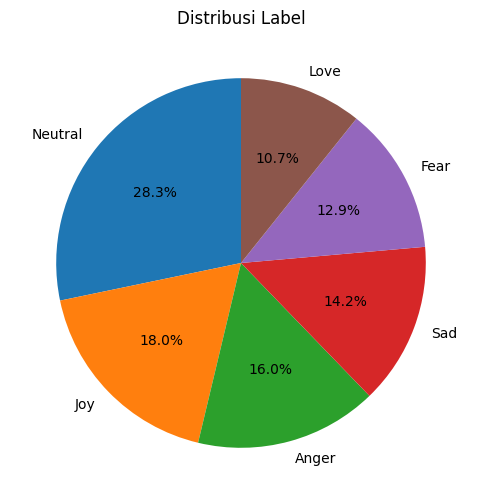

In [10]:
value_counts = df['Label'].value_counts().reset_index()
value_counts.columns = ['Labels', 'Count']

plt.figure(figsize=(6, 6))
plt.pie(
    value_counts['Count'],
    labels=value_counts['Labels'],
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.tab10.colors
)
plt.title('Distribusi Label')

# Pembagian Data

In [11]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['Tweet'], df['Label'], 
    test_size=0.30,        # 30% sisanya untuk val + test
    stratify= df['Label'], 
    random_state=42
)

# Tahap 2: Pisahkan data val (15%) dan test (15%) dari sisa 30%
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, 
    test_size=0.50,        # 50% dari 30% = 15% total
    stratify=temp_labels, 
    random_state=42
)

In [12]:
print(f"Train size     : {len(train_texts)} ({len(train_texts)/len(df):.2%})")
print(f"Validation size: {len(val_texts)} ({len(val_texts)/len(df):.2%})")
print(f"Test size      : {len(test_texts)} ({len(test_texts)/len(df):.2%})")

Train size     : 4956 (70.00%)
Validation size: 1062 (15.00%)
Test size      : 1062 (15.00%)


# Pra-pemrosesan Data

In [13]:
tokenizer = AutoTokenizer.from_pretrained("indolem/indobertweet-base-uncased")

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [14]:
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_labels)
val_labels = label_encoder.transform(val_labels)
test_labels = label_encoder.transform(test_labels)

train_texts = train_texts.tolist()
val_texts = val_texts.tolist()
test_texts = test_texts.tolist()

train_labels = np.array(train_labels, dtype=int)
val_labels = np.array(val_labels, dtype=int)
test_labels = np.array(test_labels, dtype=int)

class_names = label_encoder.classes_
print(class_names)

['Anger' 'Fear' 'Joy' 'Love' 'Neutral' 'Sad']


In [15]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')


train_dataset = torch.utils.data.TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], torch.tensor(train_labels,dtype=torch.long))
val_dataset = torch.utils.data.TensorDataset(val_encodings['input_ids'], val_encodings['attention_mask'], torch.tensor(val_labels,dtype=torch.long))
test_dataset = torch.utils.data.TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], torch.tensor(test_labels,dtype=torch.long))

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [16]:
print(train_texts[1])

kak laraa cepet sembuh yallah sedih bgt, istirahat banyak-banyak


In [17]:
teks = tokenizer.convert_ids_to_tokens(train_encodings["input_ids"][1])
print(teks)

['[CLS]', 'kak', 'lara', '##a', 'cepet', 'sembuh', 'yallah', 'sedih', 'bgt', ',', 'istirahat', 'banyak', '-', 'banyak', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]'

In [18]:
print(train_encodings["input_ids"][1])

tensor([    3,  3638, 29926,   936,  7196, 10698, 26485,  8647,  6048,    16,
        10971,  1814,    17,  1814,     4,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0])

In [19]:
print(train_encodings["attention_mask"][1])

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])


# Pemodelan

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [21]:
class_weights = compute_class_weight(
class_weight='balanced',
classes=np.unique(train_labels),
y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)

tensor([1.0442, 1.2947, 0.9260, 1.5526, 0.5896, 1.1766])


In [22]:
class EmotionClassifier(nn.Module):
    def __init__(self, transformer_model, num_classes, dropout_rate):
        super().__init__()
        self.transformer = transformer_model
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).type_as(hidden)
        pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return self.fc(self.dropout(pooled))

In [23]:
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = None if alpha is None else torch.as_tensor(alpha, dtype=torch.float32)

    def forward(self, inputs, targets):
        targets = targets.long()

        # Hitung log-softmax untuk stabilitas numerik
        log_p = F.log_softmax(inputs, dim=-1)          # (B, C)
        log_pt = log_p[torch.arange(len(inputs)), targets]  # (B,)
        pt = log_pt.exp()

        # Bobot per kelas (jika alpha diberikan)
        if self.alpha is not None:
            alpha_t = self.alpha.to(inputs.device)[targets]
        else:
            alpha_t = 1.0

        # Rumus focal loss: -alpha * (1 - pt)^gamma * log(pt)
        loss = -alpha_t * (1 - pt) ** self.gamma * log_pt

        # Default reduction = mean (standar untuk training)
        return loss.mean()

In [24]:
LOG_DIR = "log_file"


def log_epoch(loss_type, epoch, train_loss, train_acc, train_f1_macro, val_loss, val_acc, val_f1_macro):
    os.makedirs(LOG_DIR, exist_ok=True)
    log_path = os.path.join(LOG_DIR, f"{loss_type}.csv")

    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "train_acc": float(train_acc),
        "train_f1_macro": float(train_f1_macro),
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
        "val_f1_macro": float(val_f1_macro),
    }

    write_header = not os.path.exists(log_path)
    with open(log_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
            writer.writeheader()
        writer.writerow(row)

In [25]:
def log_test(loss_type, loss, acc, f1_macro):
    os.makedirs(LOG_DIR, exist_ok=True)
    log_path = os.path.join(LOG_DIR, f"{loss_type}_test.csv")

    row = {
        "loss": float(loss),
        "acc": float(acc),
        "f1_macro": float(f1_macro),
    }

    write_header = not os.path.exists(log_path)
    with open(log_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if write_header:
            writer.writeheader()
        writer.writerow(row)

In [26]:
def read_metrics(path):
    epochs, train_loss, train_acc, train_f1, val_loss, val_acc, val_f1 = [], [], [], [], [], [], []
    with open(path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            epochs.append(int(row["epoch"]))
            train_loss.append(float(row["train_loss"]))
            train_acc.append(float(row["train_acc"]))
            train_f1.append(float(row["train_f1_macro"]))
            val_loss.append(float(row["val_loss"]))
            val_acc.append(float(row["val_acc"]))
            val_f1.append(float(row["val_f1_macro"]))
    return epochs, train_loss, train_acc, train_f1, val_loss, val_acc, val_f1

In [27]:
def read_metrics_test(path):
    loss, acc, f1 = [], [], []
    with open(path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            loss.append(float(row["loss"]))
            acc.append(float(row["acc"]))
            f1.append(float(row["f1_macro"]))
    return loss, acc, f1

In [28]:
MODEL_DIR = "model_file"
os.makedirs(MODEL_DIR, exist_ok=True)

In [29]:
model = AutoModel.from_pretrained("indolem/indobertweet-base-uncased")

2025-10-23 11:39:08.747902: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761219548.932629      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761219548.984372      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

# Cross-Entropy

In [30]:
model_base = EmotionClassifier(model, NUM_CLASSES, DROPOUT_RATE).to(device)

optimizer = torch.optim.AdamW(model_base.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

In [31]:
# Inisialisasi variabel untuk melacak loss terbaik
best_val_f1 = -1.0
# Tentukan path untuk menyimpan model terbaik
best_model_path_base = os.path.join(MODEL_DIR, "best_model_base.pth")
# Inisialisasi penghitung epoch tanpa perbaikan
epochs_no_improve = 0
# ===================================================================

# Hitung total waktu training
total_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # Timer per epoch
    epoch_start_time = time.time()
    
    model_base.train()
    total_loss = 0.0
    total_correct = 0
    train_predicted, train_labels = [], []
    
    # Progress bar untuk training
    train_progress = tqdm(
        train_dataloader, 
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Training]", 
        leave=False
    )
    
    for batch in train_progress:
        input_ids, attention_mask, labels = batch
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_base(input_ids, attention_mask)
        labels = labels.long()
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Update loss & akurasi
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_correct += (predicted == labels).sum().item()

        train_predicted.extend(predicted.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
        
        # Update progress bar dengan loss/akurasi
        train_progress.set_postfix({
            'Loss': f"{loss.item():.4f}",
            'Acc': f"{(predicted == labels).sum().item() / len(labels):.2f}"
        })
    
    # Hitung metrik training
    train_loss = total_loss / len(train_dataloader)
    train_accuracy = total_correct / len(train_dataset)
    train_f1_macro = f1_score(train_labels, train_predicted, average='macro')
    
    # Timer epoch
    epoch_time = time.time() - epoch_start_time
    
    # Validation loop dengan progress bar
    model_base.eval()
    total_val_loss = 0.0
    total_val_correct = 0
    val_predicted = []
    val_labels = []
    
    val_progress = tqdm(val_dataloader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Validation]", leave=False)
    
    with torch.no_grad():
        for batch in val_progress:
            input_ids, attention_mask, labels = batch
            input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
            
            outputs = model_base(input_ids, attention_mask)
            labels = labels.long()
            
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total_val_correct += (predicted == labels).sum().item()
            val_predicted.extend(predicted.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
            
            val_progress.set_postfix({
                'Val Loss': f"{loss.item():.4f}",
                'Val Acc': f"{(predicted == labels).sum().item() / len(labels):.2f}"
            })
    
    # Hitung metrik validasi
    val_loss = total_val_loss / len(val_dataloader)
    val_accuracy = total_val_correct / len(val_dataset)
    val_f1_macro = f1_score(val_labels, val_predicted, average='macro')
    
    # Tampilkan hasil per epoch
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Time: {epoch_time // 60:.0f}m {epoch_time % 60:.0f}s | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f} | Train f1_macro: {train_f1_macro:.2f} |"
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f} Val f1_macro: {val_f1_macro:.2f}"
    )

    log_epoch("cross-entropy", epoch + 1, train_loss, train_accuracy, train_f1_macro, val_loss, val_accuracy, val_f1_macro)

    # ===================================================================
    # ===== LOGIKA CHECKPOINTING & EARLY STOPPING =====
    # ===================================================================
    # Periksa apakah validation loss saat ini adalah yang terbaik
    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        # Simpan model state_dict jika lebih baik
        torch.save(model_base.state_dict(), best_model_path_base)
        print(f"  ->Val F1 Macro membaik! Menyimpan model terbaik ke {best_model_path_base}")
        # Reset penghitung jika performa membaik
        epochs_no_improve = 0
    else:
        # Tambah penghitung jika performa tidak membaik
        epochs_no_improve += 1
        print(f"  -> Val F1 Macro tidak membaik. Kesabaran: {epochs_no_improve}/{PATIENCE}")

    # Periksa apakah batas kesabaran sudah tercapai
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping dipicu setelah {PATIENCE} epoch tanpa perbaikan.")
        break # Hentikan training loop
    # ===================================================================


# Total waktu training
total_time = time.time() - total_start_time
print(f"\nTotal Training Time: {total_time // 60:.0f}m {total_time % 60:.0f}s")

Epoch 1/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Epoch 1/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 1/50 | Time: 0m 59s | Train Loss: 1.6163 | Train Acc: 0.35 | Train f1_macro: 0.25 |Val Loss: 1.4299 | Val Acc: 0.50 Val f1_macro: 0.44
  ->Val F1 Macro membaik! Menyimpan model terbaik ke model_file/best_model_base.pth


Epoch 2/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

...

Epoch 10/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 10/50 | Time: 1m 0s | Train Loss: 0.2826 | Train Acc: 0.91 | Train f1_macro: 0.91 |Val Loss: 0.6601 | Val Acc: 0.77 Val f1_macro: 0.78
  -> Val F1 Macro tidak membaik. Kesabaran: 2/3


Epoch 11/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 11/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 11/50 | Time: 1m 0s | Train Loss: 0.2367 | Train Acc: 0.92 | Train f1_macro: 0.93 |Val Loss: 0.6942 | Val Acc: 0.77 Val f1_macro: 0.78
  -> Val F1 Macro tidak membaik. Kesabaran: 3/3

Early stopping dipicu setelah 3 epoch tanpa perbaikan.

Total Training Time: 11m 47s


In [32]:
path_skenario = "log_file/cross-entropy.csv"

e, tl, ta, tf, vl, va, vf = read_metrics(path_skenario)
name = os.path.splitext(os.path.basename(path_skenario))[0]

Grafik disimpan ke: chart_file/cross-entropy_train_val_loss.png


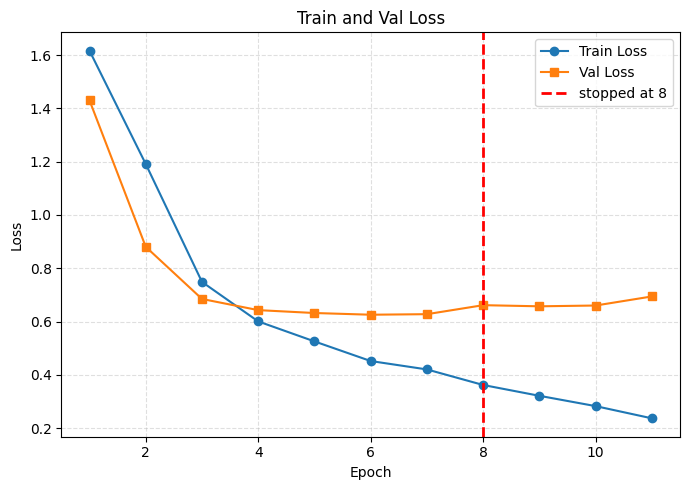

In [33]:
plt.figure(figsize=(7, 5))
plt.plot(e, tl, label="Train Loss", marker='o')
plt.plot(e, vl, label="Val Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train and Val Loss")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_loss.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

# Tampilkan di output cell
plt.show()

# Tutup plot (opsional di Kaggle untuk mencegah memory leak)
plt.close()

Grafik disimpan ke: chart_file/cross-entropy_train_val_accuracy.png


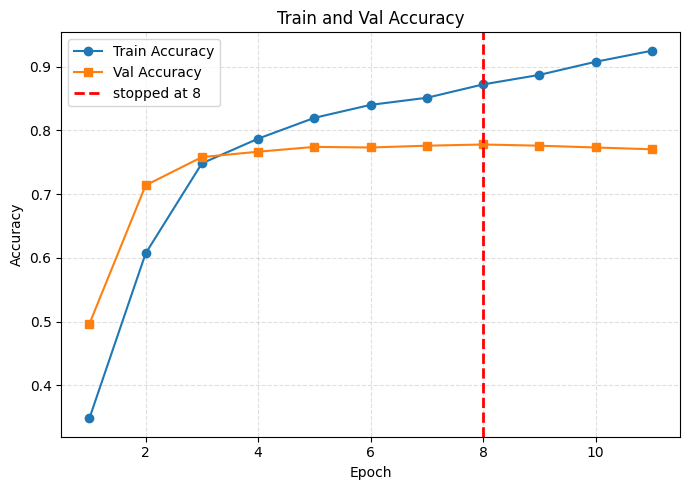

In [34]:
plt.figure(figsize=(7, 5))
plt.plot(e, ta, label="Train Accuracy", marker='o')
plt.plot(e, va, label="Val Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train and Val Accuracy")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_accuracy.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

# Tampilkan di output cell
plt.show()

# Tutup plot (opsional di Kaggle untuk mencegah memory leak)
plt.close()

Grafik disimpan ke: chart_file/cross-entropy_train_val_f1_macro.png


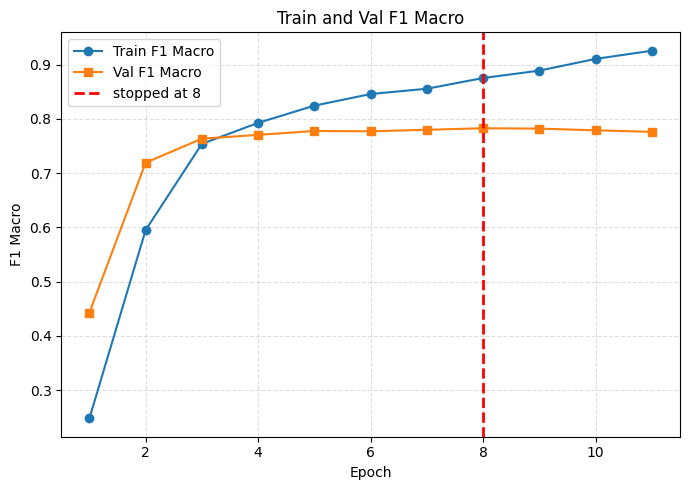

In [35]:
plt.figure(figsize=(7, 5))
plt.plot(e, tf, label="Train F1 Macro", marker='o')
plt.plot(e, vf, label="Val F1 Macro", marker='s')
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.title("Train and Val F1 Macro")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_f1_macro.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

# Tampilkan di output cell
plt.show()

# Tutup plot (opsional di Kaggle untuk mencegah memory leak)
plt.close()

In [36]:
model_terbaik_base = EmotionClassifier(model, NUM_CLASSES, DROPOUT_RATE).to(device)

model_terbaik_base.load_state_dict(torch.load(best_model_path_base))
model_terbaik_base.eval()

print("MODEL BASE terbaik berhasil dimuat.")

MODEL BASE terbaik berhasil dimuat.


In [37]:
final_predictions = []
final_true_labels = []
total_samples = 0
total_loss = 0

# Matikan perhitungan gradien untuk evaluasi
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Mengevaluasi MODEL BASE terbaik"):
        input_ids, attention_mask, labels = batch
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        
        # Dapatkan output dari model terbaik
        outputs = model_terbaik_base(input_ids, attention_mask)

        # Hitung loss untuk batch ini
        loss = criterion(outputs, labels)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        
        # Dapatkan prediksi kelas
        _, predicted = torch.max(outputs, 1)
        
        # Kumpulkan prediksi dan label asli
        final_predictions.extend(predicted.cpu().numpy())
        final_true_labels.extend(labels.cpu().numpy())

Mengevaluasi MODEL BASE terbaik:   0%|          | 0/34 [00:00<?, ?it/s]

In [38]:
acc = accuracy_score(final_true_labels, final_predictions)
prec = precision_score(final_true_labels, final_predictions, average='macro')
rec = recall_score(final_true_labels, final_predictions, average='macro')
f1 = f1_score(final_true_labels, final_predictions, average='macro')

log_test("cross-entropy", loss, acc, f1)

print(f"acc: {acc}")
print(f"prec: {prec}")
print(f"rec: {rec}")
print(f"f1: {f1}")
print(f"loss: {loss}")

acc: 0.7871939736346516
prec: 0.792589743769553
rec: 0.7991850490196079
f1: 0.7952051526365452
loss: 0.8697018027305603


--- Laporan Klasifikasi Model Terbaik ---
              precision    recall  f1-score   support

       Anger       0.84      0.80      0.82       170
        Fear       0.84      0.84      0.84       136
         Joy       0.80      0.80      0.80       192
        Love       0.73      0.83      0.78       114
     Neutral       0.74      0.73      0.74       300
         Sad       0.79      0.80      0.80       150

    accuracy                           0.79      1062
   macro avg       0.79      0.80      0.80      1062
weighted avg       0.79      0.79      0.79      1062


--- Confusion Matrix ---
Grafik disimpan ke: chart_file/cross-entropy_confusion_matrix.png


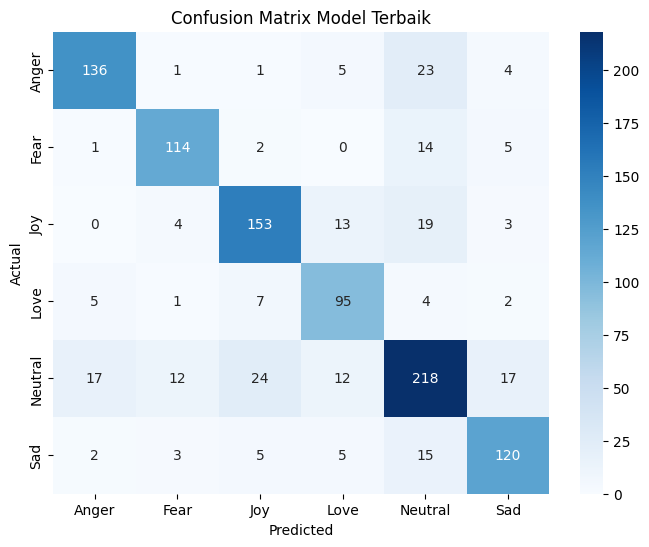

In [39]:
# Tampilkan Classification Report
print("--- Laporan Klasifikasi Model Terbaik ---")
report = classification_report(
    final_true_labels, 
    final_predictions, 
    target_names=class_names
)
print(report)

# Tampilkan Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(final_true_labels, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Model Terbaik')
save_path = os.path.join(CHART_DIR, f"{name}_confusion_matrix.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")
plt.show()
plt.close()

# Weighted Cross Entropy

In [40]:
model_csl = EmotionClassifier(model, NUM_CLASSES, DROPOUT_RATE).to(device)

optimizer = torch.optim.AdamW(model_csl.parameters(), lr=LEARNING_RATE)
criterion = FocalLoss(alpha=class_weights, gamma=1.0)

In [41]:
# Inisialisasi variabel untuk melacak loss terbaik
best_val_f1 = -1.0
# Tentukan path untuk menyimpan model terbaik
best_model_path_csl = os.path.join(MODEL_DIR, "best_model_csl.pth")
# Tentukan 'kesabaran' untuk early stopping
# Inisialisasi penghitung epoch tanpa perbaikan
epochs_no_improve = 0
# ===================================================================

# Hitung total waktu training
total_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # Timer per epoch
    epoch_start_time = time.time()
    
    model_csl.train()
    total_loss = 0.0
    total_correct = 0
    
    # Progress bar untuk training
    train_progress = tqdm(
        train_dataloader, 
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Training]", 
        leave=False
    )
    
    for batch in train_progress:
        input_ids, attention_mask, labels = batch
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_csl(input_ids, attention_mask)
        labels = labels.long()
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Update loss & akurasi
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_correct += (predicted == labels).sum().item()

        train_predicted.extend(predicted.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
        
        # Update progress bar dengan loss/akurasi
        train_progress.set_postfix({
            'Loss': f"{loss.item():.4f}",
            'Acc': f"{(predicted == labels).sum().item() / len(labels):.2f}"
        })
    
    # Hitung metrik training
    train_loss = total_loss / len(train_dataloader)
    train_accuracy = total_correct / len(train_dataset)
    train_f1_macro = f1_score(train_labels, train_predicted, average='macro')
    
    # Timer epoch
    epoch_time = time.time() - epoch_start_time
    
    # Validation loop dengan progress bar
    model_csl.eval()
    total_val_loss = 0.0
    total_val_correct = 0
    val_predicted = []
    val_labels = []
    
    val_progress = tqdm(val_dataloader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Validation]", leave=False)
    
    with torch.no_grad():
        for batch in val_progress:
            input_ids, attention_mask, labels = batch
            input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
            
            outputs = model_csl(input_ids, attention_mask)
            labels = labels.long()
            
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total_val_correct += (predicted == labels).sum().item()
            val_predicted.extend(predicted.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
            
            val_progress.set_postfix({
                'Val Loss': f"{loss.item():.4f}",
                'Val Acc': f"{(predicted == labels).sum().item() / len(labels):.2f}"
            })
    
    # Hitung metrik validasi
    val_loss = total_val_loss / len(val_dataloader)
    val_accuracy = total_val_correct / len(val_dataset)
    val_f1_macro = f1_score(val_labels, val_predicted, average='macro')
    
    # Tampilkan hasil per epoch
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Time: {epoch_time // 60:.0f}m {epoch_time % 60:.0f}s | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f} | Train f1_macro: {train_f1_macro:.2f} |"
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f} Val f1_macro: {val_f1_macro:.2f}"
    )

    log_epoch("weighted-cross-entropy", epoch + 1, train_loss, train_accuracy, train_f1_macro, val_loss, val_accuracy, val_f1_macro)

    # ===================================================================
    # ===== LOGIKA CHECKPOINTING & EARLY STOPPING =====
    # ===================================================================
    # Periksa apakah validation loss saat ini adalah yang terbaik
    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        # Simpan model state_dict jika lebih baik
        torch.save(model_csl.state_dict(), best_model_path_csl)
        print(f"  -> Val F1 Macro membaik! Menyimpan model terbaik ke {best_model_path_csl}")
        # Reset penghitung jika performa membaik
        epochs_no_improve = 0
    else:
        # Tambah penghitung jika performa tidak membaik
        epochs_no_improve += 1
        print(f"  -> Val F1 Macro tidak membaik. Kesabaran: {epochs_no_improve}/{PATIENCE}")

    # Periksa apakah batas kesabaran sudah tercapai
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping dipicu setelah {PATIENCE} epoch tanpa perbaikan.")
        break # Hentikan training loop
    # ===================================================================


# Total waktu training
total_time = time.time() - total_start_time
print(f"\nTotal Training Time: {total_time // 60:.0f}m {total_time % 60:.0f}s")

Epoch 1/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 1/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 1/50 | Time: 1m 1s | Train Loss: 0.5577 | Train Acc: 0.73 | Train f1_macro: 0.83 |Val Loss: 0.4668 | Val Acc: 0.75 Val f1_macro: 0.76
  -> Val F1 Macro membaik! Menyimpan model terbaik ke model_file/best_model_csl.pth


Epoch 2/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 2/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

...

Epoch 5/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 5/50 | Time: 1m 1s | Train Loss: 0.1368 | Train Acc: 0.92 | Train f1_macro: 0.88 |Val Loss: 0.5110 | Val Acc: 0.77 Val f1_macro: 0.78
  -> Val F1 Macro tidak membaik. Kesabaran: 2/3


Epoch 6/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 6/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 6/50 | Time: 1m 1s | Train Loss: 0.1046 | Train Acc: 0.93 | Train f1_macro: 0.88 |Val Loss: 0.5123 | Val Acc: 0.77 Val f1_macro: 0.78
  -> Val F1 Macro tidak membaik. Kesabaran: 3/3

Early stopping dipicu setelah 3 epoch tanpa perbaikan.

Total Training Time: 6m 28s


In [42]:
path_skenario = "log_file/weighted-cross-entropy.csv"

e, tl, ta, tf, vl, va, vf = read_metrics(path_skenario)
name = os.path.splitext(os.path.basename(path_skenario))[0]

Grafik disimpan ke: chart_file/weighted-cross-entropy_train_val_loss.png


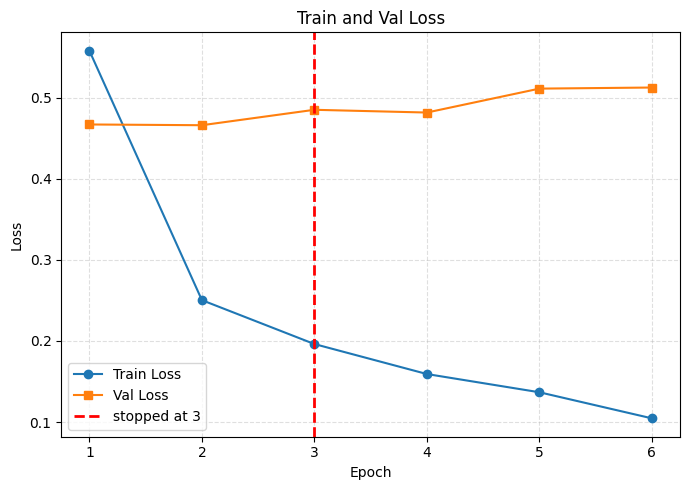

In [43]:
plt.figure(figsize=(7, 5))
plt.plot(e, tl, label="Train Loss", marker='o')
plt.plot(e, vl, label="Val Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train and Val Loss")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_loss.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

# Tampilkan di output cell
plt.show()

# Tutup plot (opsional di Kaggle untuk mencegah memory leak)
plt.close()

Grafik disimpan ke: chart_file/weighted-cross-entropy_train_val_accuracy.png


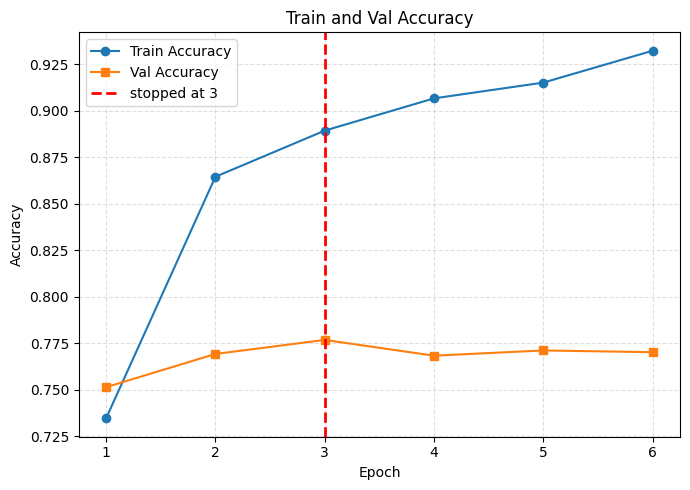

In [44]:
plt.figure(figsize=(7, 5))
plt.plot(e, ta, label="Train Accuracy", marker='o')
plt.plot(e, va, label="Val Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train and Val Accuracy")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_accuracy.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

# Tampilkan di output cell
plt.show()

# Tutup plot (opsional di Kaggle untuk mencegah memory leak)
plt.close()

Grafik disimpan ke: chart_file/weighted-cross-entropy_train_val_f1_macro.png


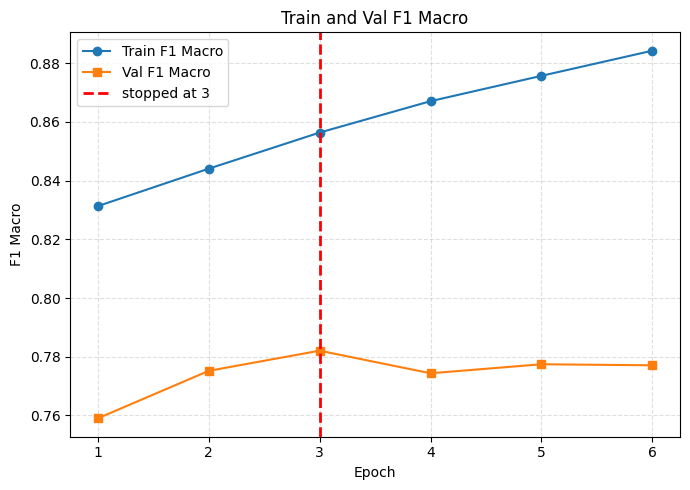

In [45]:
plt.figure(figsize=(7, 5))
plt.plot(e, tf, label="Train F1 Macro", marker='o')
plt.plot(e, vf, label="Val F1 Macro", marker='s')
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.title("Train and Val F1 Macro")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_f1_macro.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

plt.show()
plt.close()

In [46]:
model_terbaik_csl = EmotionClassifier(model, NUM_CLASSES, DROPOUT_RATE).to(device)

# Muat bobot yang sudah disimpan
model_terbaik_csl.load_state_dict(torch.load(best_model_path_csl))

# Set model ke mode evaluasi
model_terbaik_csl.eval()

print("MODEL WEIGHTED CE terbaik berhasil dimuat.")

MODEL WEIGHTED CE terbaik berhasil dimuat.


In [47]:
final_predictions = []
final_true_labels = []
total_samples = 0
total_loss = 0

# Matikan perhitungan gradien untuk evaluasi
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Mengevaluasi MODEL BASE terbaik"):
        input_ids, attention_mask, labels = batch
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        
        # Dapatkan output dari model terbaik
        outputs = model_terbaik_base(input_ids, attention_mask)

        # Hitung loss untuk batch ini
        loss = criterion(outputs, labels)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        
        # Dapatkan prediksi kelas
        _, predicted = torch.max(outputs, 1)
        
        # Kumpulkan prediksi dan label asli
        final_predictions.extend(predicted.cpu().numpy())
        final_true_labels.extend(labels.cpu().numpy())

Mengevaluasi MODEL BASE terbaik:   0%|          | 0/34 [00:00<?, ?it/s]

In [48]:
acc = accuracy_score(final_true_labels, final_predictions)
prec = precision_score(final_true_labels, final_predictions, average='macro')
rec = recall_score(final_true_labels, final_predictions, average='macro')
f1 = f1_score(final_true_labels, final_predictions, average='macro')

log_test("weighted-cross-entropy", loss, acc, f1)

print(f"acc: {acc}")
print(f"prec: {prec}")
print(f"rec: {rec}")
print(f"f1: {f1}")
print(f"loss: {loss}")

acc: 0.7777777777777778
prec: 0.7847518766102216
rec: 0.8097789817681459
f1: 0.7903425039458062
loss: 0.39901304244995117


--- Laporan Klasifikasi Model Terbaik ---
              precision    recall  f1-score   support

       Anger       0.69      0.92      0.79       170
        Fear       0.87      0.85      0.86       136
         Joy       0.76      0.83      0.80       192
        Love       0.77      0.84      0.81       114
     Neutral       0.82      0.57      0.67       300
         Sad       0.79      0.85      0.82       150

    accuracy                           0.78      1062
   macro avg       0.78      0.81      0.79      1062
weighted avg       0.79      0.78      0.77      1062


--- Confusion Matrix ---
Grafik disimpan ke: chart_file/weighted-cross-entropy_confusion_matrix.png


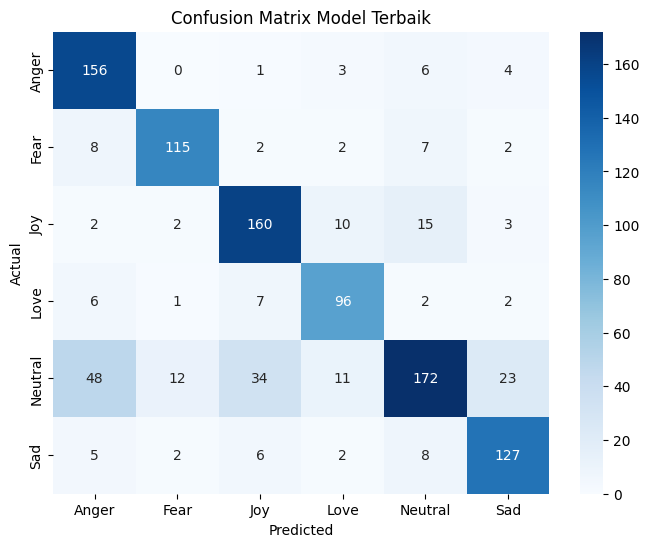

In [49]:
# Tampilkan Classification Report
print("--- Laporan Klasifikasi Model Terbaik ---")
report = classification_report(
    final_true_labels, 
    final_predictions, 
    target_names=class_names
)
print(report)

# Tampilkan Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(final_true_labels, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Model Terbaik')
save_path = os.path.join(CHART_DIR, f"{name}_confusion_matrix.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")
plt.show()
plt.close()

# Focal Loss Gamma

In [50]:
model_focal1 = EmotionClassifier(model, NUM_CLASSES, DROPOUT_RATE).to(device)

optimizer = torch.optim.AdamW(model_focal1.parameters(), lr=LEARNING_RATE)
criterion = FocalLoss(alpha=None, gamma=2.0)

In [51]:
# Inisialisasi variabel untuk melacak loss terbaik
best_val_f1 = -1.0
# Tentukan path untuk menyimpan model terbaik
best_model_path_focal1 = os.path.join(MODEL_DIR, "best_model_focal1.pth")
# Tentukan 'kesabaran' untuk early stopping
# Inisialisasi penghitung epoch tanpa perbaikan
epochs_no_improve = 0
# ===================================================================

# Hitung total waktu training
total_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # Timer per epoch
    epoch_start_time = time.time()
    
    model_focal1.train()
    total_loss = 0.0
    total_correct = 0
    
    # Progress bar untuk training
    train_progress = tqdm(
        train_dataloader, 
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Training]", 
        leave=False
    )
    
    for batch in train_progress:
        input_ids, attention_mask, labels = batch
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_focal1(input_ids, attention_mask)
        labels = labels.long()
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Update loss & akurasi
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_correct += (predicted == labels).sum().item()

        train_predicted.extend(predicted.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
        
        # Update progress bar dengan loss/akurasi
        train_progress.set_postfix({
            'Loss': f"{loss.item():.4f}",
            'Acc': f"{(predicted == labels).sum().item() / len(labels):.2f}"
        })
    
    # Hitung metrik training
    train_loss = total_loss / len(train_dataloader)
    train_accuracy = total_correct / len(train_dataset)
    train_f1_macro = f1_score(train_labels, train_predicted, average='macro')
    
    # Timer epoch
    epoch_time = time.time() - epoch_start_time
    
    # Validation loop dengan progress bar
    model_focal1.eval()
    total_val_loss = 0.0
    total_val_correct = 0
    val_predicted = []
    val_labels = []
    
    val_progress = tqdm(val_dataloader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Validation]", leave=False)
    
    with torch.no_grad():
        for batch in val_progress:
            input_ids, attention_mask, labels = batch
            input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
            
            outputs = model_focal1(input_ids, attention_mask)
            labels = labels.long()
            
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total_val_correct += (predicted == labels).sum().item()
            val_predicted.extend(predicted.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
            
            val_progress.set_postfix({
                'Val Loss': f"{loss.item():.4f}",
                'Val Acc': f"{(predicted == labels).sum().item() / len(labels):.2f}"
            })
    
    # Hitung metrik validasi
    val_loss = total_val_loss / len(val_dataloader)
    val_accuracy = total_val_correct / len(val_dataset)
    val_f1_macro = f1_score(val_labels, val_predicted, average='macro')
    
    # Tampilkan hasil per epoch
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Time: {epoch_time // 60:.0f}m {epoch_time % 60:.0f}s | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f} | Train f1_macro: {train_f1_macro:.2f} |"
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f} Val f1_macro: {val_f1_macro:.2f}"
    )

    log_epoch("focal-loss-gamma", epoch + 1, train_loss, train_accuracy, train_f1_macro, val_loss, val_accuracy, val_f1_macro)

    # ===================================================================
    # ===== LOGIKA CHECKPOINTING & EARLY STOPPING =====
    # ===================================================================
    # Periksa apakah validation loss saat ini adalah yang terbaik
    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        # Simpan model state_dict jika lebih baik
        torch.save(model_focal1.state_dict(), best_model_path_focal1)
        print(f"  -> Val F1 Macro membaik! Menyimpan model terbaik ke {best_model_path_focal1}")
        # Reset penghitung jika performa membaik
        epochs_no_improve = 0
    else:
        # Tambah penghitung jika performa tidak membaik
        epochs_no_improve += 1
        print(f"  -> Val F1 Macro tidak membaik. Kesabaran: {epochs_no_improve}/{PATIENCE}")

    # Periksa apakah batas kesabaran sudah tercapai
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping dipicu setelah {PATIENCE} epoch tanpa perbaikan.")
        break # Hentikan training loop
    # ===================================================================


# Total waktu training
total_time = time.time() - total_start_time
print(f"\nTotal Training Time: {total_time // 60:.0f}m {total_time % 60:.0f}s")

Epoch 1/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 1/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 1/50 | Time: 1m 1s | Train Loss: 0.2865 | Train Acc: 0.83 | Train f1_macro: 0.88 |Val Loss: 0.3773 | Val Acc: 0.78 Val f1_macro: 0.79
  -> Val F1 Macro membaik! Menyimpan model terbaik ke model_file/best_model_focal1.pth


Epoch 2/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 2/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

...

Epoch 3/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 3/50 | Time: 1m 1s | Train Loss: 0.1033 | Train Acc: 0.92 | Train f1_macro: 0.89 |Val Loss: 0.4103 | Val Acc: 0.77 Val f1_macro: 0.78
  -> Val F1 Macro tidak membaik. Kesabaran: 2/3


Epoch 4/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 4/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 4/50 | Time: 1m 1s | Train Loss: 0.0864 | Train Acc: 0.93 | Train f1_macro: 0.89 |Val Loss: 0.4270 | Val Acc: 0.78 Val f1_macro: 0.78
  -> Val F1 Macro tidak membaik. Kesabaran: 3/3

Early stopping dipicu setelah 3 epoch tanpa perbaikan.

Total Training Time: 4m 18s


In [52]:
path_skenario = "log_file/focal-loss-gamma.csv"

e, tl, ta, tf, vl, va, vf = read_metrics(path_skenario)
name = os.path.splitext(os.path.basename(path_skenario))[0]

Grafik disimpan ke: chart_file/focal-loss-gamma_train_val_loss.png


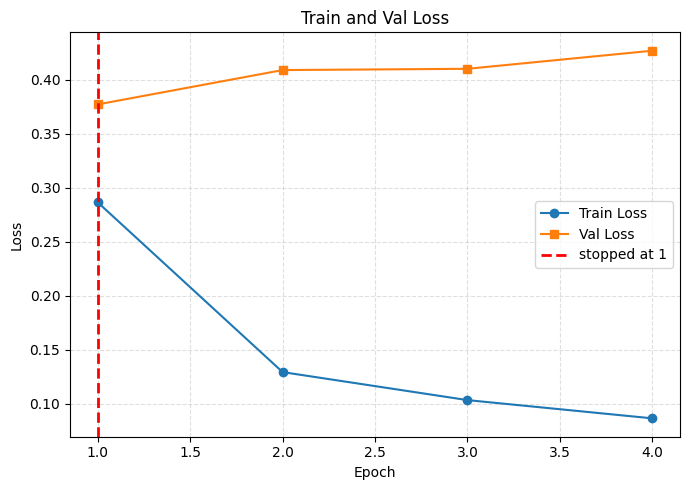

In [53]:
plt.figure(figsize=(7, 5))
plt.plot(e, tl, label="Train Loss", marker='o')
plt.plot(e, vl, label="Val Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train and Val Loss")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_loss.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

# Tampilkan di output cell
plt.show()

# Tutup plot (opsional di Kaggle untuk mencegah memory leak)
plt.close()

Grafik disimpan ke: chart_file/focal-loss-gamma_train_val_accuracy.png


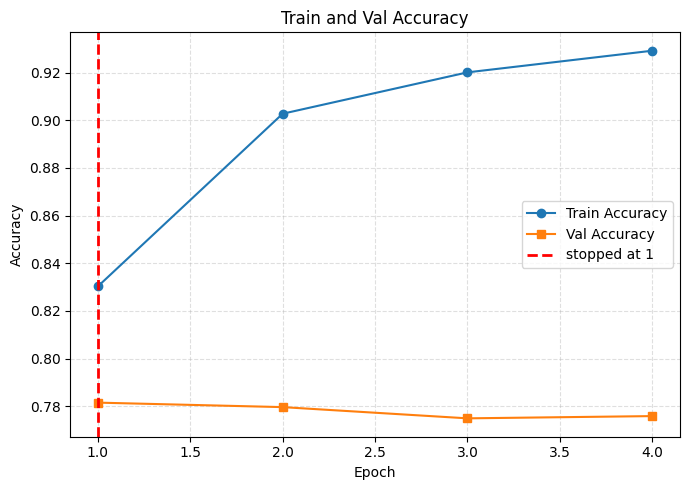

In [54]:
plt.figure(figsize=(7, 5))
plt.plot(e, ta, label="Train Accuracy", marker='o')
plt.plot(e, va, label="Val Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train and Val Accuracy")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_accuracy.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

# Tampilkan di output cell
plt.show()

# Tutup plot (opsional di Kaggle untuk mencegah memory leak)
plt.close()

Grafik disimpan ke: chart_file/focal-loss-gamma_train_val_f1_macro.png


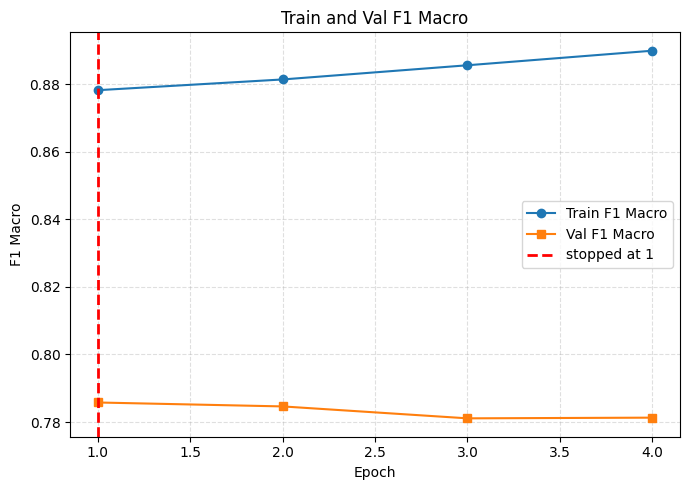

In [55]:
plt.figure(figsize=(7, 5))
plt.plot(e, tf, label="Train F1 Macro", marker='o')
plt.plot(e, vf, label="Val F1 Macro", marker='s')
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.title("Train and Val F1 Macro")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_f1_macro.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")
plt.show()
plt.close()

In [56]:
# Buat instance baru dari arsitektur model
# Pastikan base_model masih ada dari proses loading sebelumnya
model_terbaik_focal1 = EmotionClassifier(model, NUM_CLASSES,DROPOUT_RATE).to(device)

# Muat bobot yang sudah disimpan
model_terbaik_focal1.load_state_dict(torch.load(best_model_path_focal1))

# Set model ke mode evaluasi
model_terbaik_focal1.eval()

print("MODEL FOCAL LOSS GAMMA terbaik berhasil dimuat.")

MODEL FOCAL LOSS GAMMA terbaik berhasil dimuat.


In [57]:
final_predictions = []
final_true_labels = []

# Matikan perhitungan gradien untuk evaluasi
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Mengevaluasi FOCAL LOSS GAMMA terbaik"):
        input_ids, attention_mask, labels = batch
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        
        # Dapatkan output dari model terbaik
        outputs = model_terbaik_focal1(input_ids, attention_mask)

        # Hitung loss untuk batch ini
        loss = criterion(outputs, labels)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        
        # Dapatkan prediksi kelas
        _, predicted = torch.max(outputs, 1)
        
        # Kumpulkan prediksi dan label asli
        final_predictions.extend(predicted.cpu().numpy())
        final_true_labels.extend(labels.cpu().numpy())

Mengevaluasi FOCAL LOSS GAMMA terbaik:   0%|          | 0/34 [00:00<?, ?it/s]

In [58]:
acc = accuracy_score(final_true_labels, final_predictions)
prec = precision_score(final_true_labels, final_predictions, average='macro')
rec = recall_score(final_true_labels, final_predictions, average='macro')
f1 = f1_score(final_true_labels, final_predictions, average='macro')

log_test("focal-loss-gamma", loss, acc, f1)

print(f"acc: {acc}")
print(f"prec: {prec}")
print(f"rec: {rec}")
print(f"f1: {f1}")
print(f"loss: {loss}")

acc: 0.7853107344632768
prec: 0.7856945232842093
rec: 0.8093169504643963
f1: 0.7952893574716574
loss: 0.5296167731285095


--- Laporan Klasifikasi Model Terbaik ---
              precision    recall  f1-score   support

       Anger       0.80      0.86      0.83       170
        Fear       0.84      0.84      0.84       136
         Joy       0.78      0.80      0.79       192
        Love       0.73      0.85      0.79       114
     Neutral       0.78      0.65      0.71       300
         Sad       0.79      0.85      0.82       150

    accuracy                           0.79      1062
   macro avg       0.79      0.81      0.80      1062
weighted avg       0.79      0.79      0.78      1062


--- Confusion Matrix ---
Grafik disimpan ke: chart_file/focal-loss-gamma_confusion_matrix.png


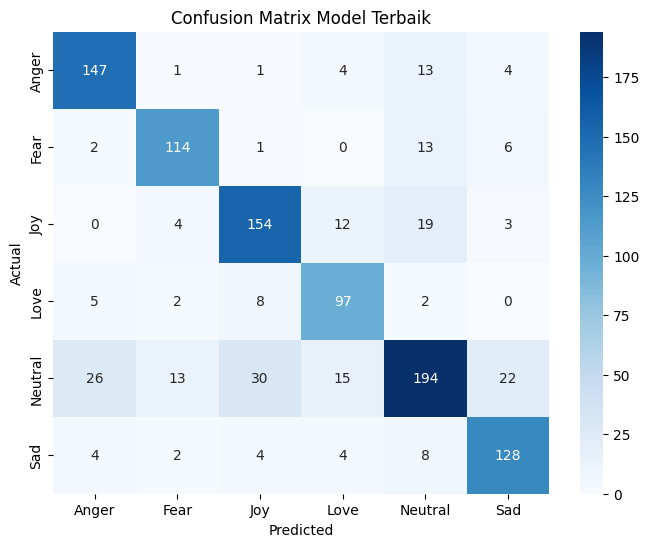

In [59]:
# Tampilkan Classification Report
print("--- Laporan Klasifikasi Model Terbaik ---")
report = classification_report(
    final_true_labels, 
    final_predictions, 
    target_names=class_names
)
print(report)

# Tampilkan Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(final_true_labels, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Model Terbaik')
save_path = os.path.join(CHART_DIR, f"{name}_confusion_matrix.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")
plt.show()
plt.close()

# Focal Loss Full

In [60]:
model_focalweight = EmotionClassifier(model, NUM_CLASSES, DROPOUT_RATE).to(device)

optimizer = torch.optim.AdamW(model_focalweight.parameters(), lr=LEARNING_RATE)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)

In [61]:
# Inisialisasi variabel untuk melacak loss terbaik
best_val_f1 = -1.0
# Tentukan path untuk menyimpan model terbaik
best_model_path_focalweight = os.path.join(MODEL_DIR, "best_model_focalweight.pth")
# Tentukan 'kesabaran' untuk early stopping
# Inisialisasi penghitung epoch tanpa perbaikan
epochs_no_improve = 0
# ===================================================================

# Hitung total waktu training
total_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # Timer per epoch
    epoch_start_time = time.time()
    
    model_focalweight.train()
    total_loss = 0.0
    total_correct = 0
    
    # Progress bar untuk training
    train_progress = tqdm(
        train_dataloader, 
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Training]", 
        leave=False
    )
    
    for batch in train_progress:
        input_ids, attention_mask, labels = batch
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_focalweight(input_ids, attention_mask)
        labels = labels.long()
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Update loss & akurasi
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_correct += (predicted == labels).sum().item()

        train_predicted.extend(predicted.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())
        
        # Update progress bar dengan loss/akurasi
        train_progress.set_postfix({
            'Loss': f"{loss.item():.4f}",
            'Acc': f"{(predicted == labels).sum().item() / len(labels):.2f}"
        })
    
    # Hitung metrik training
    train_loss = total_loss / len(train_dataloader)
    train_accuracy = total_correct / len(train_dataset)
    train_f1_macro = f1_score(train_labels, train_predicted, average='macro')
    
    # Timer epoch
    epoch_time = time.time() - epoch_start_time
    
    # Validation loop dengan progress bar
    model_focalweight.eval()
    total_val_loss = 0.0
    total_val_correct = 0
    val_predicted = []
    val_labels = []
    
    val_progress = tqdm(val_dataloader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Validation]", leave=False)
    
    with torch.no_grad():
        for batch in val_progress:
            input_ids, attention_mask, labels = batch
            input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
            
            outputs = model_focalweight(input_ids, attention_mask)
            labels = labels.long()
            
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total_val_correct += (predicted == labels).sum().item()
            val_predicted.extend(predicted.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
            
            val_progress.set_postfix({
                'Val Loss': f"{loss.item():.4f}",
                'Val Acc': f"{(predicted == labels).sum().item() / len(labels):.2f}"
            })
    
    # Hitung metrik validasi
    val_loss = total_val_loss / len(val_dataloader)
    val_accuracy = total_val_correct / len(val_dataset)
    val_f1_macro = f1_score(val_labels, val_predicted, average='macro')
    
    # Tampilkan hasil per epoch
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Time: {epoch_time // 60:.0f}m {epoch_time % 60:.0f}s | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f} | Train f1_macro: {train_f1_macro:.2f} |"
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.2f} Val f1_macro: {val_f1_macro:.2f}"
    )

    log_epoch("focal-loss-weight", epoch + 1, train_loss, train_accuracy, train_f1_macro, val_loss, val_accuracy, val_f1_macro)

    # ===================================================================
    # ===== LOGIKA CHECKPOINTING & EARLY STOPPING =====
    # ===================================================================
    # Periksa apakah validation loss saat ini adalah yang terbaik
    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        # Simpan model state_dict jika lebih baik
        torch.save(model_focalweight.state_dict(), best_model_path_focalweight)
        print(f"  -> Val F1 Macro membaik! Menyimpan model terbaik ke {best_model_path_focalweight}")
        # Reset penghitung jika performa membaik
        epochs_no_improve = 0
    else:
        # Tambah penghitung jika performa tidak membaik
        epochs_no_improve += 1
        print(f"  -> Val F1 Macro tidak membaik. Kesabaran: {epochs_no_improve}/{PATIENCE}")

    # Periksa apakah batas kesabaran sudah tercapai
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping dipicu setelah {PATIENCE} epoch tanpa perbaikan.")
        break # Hentikan training loop
    # ===================================================================


# Total waktu training
total_time = time.time() - total_start_time
print(f"\nTotal Training Time: {total_time // 60:.0f}m {total_time % 60:.0f}s")

Epoch 1/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 1/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 1/50 | Time: 1m 0s | Train Loss: 0.2866 | Train Acc: 0.82 | Train f1_macro: 0.88 |Val Loss: 0.3633 | Val Acc: 0.77 Val f1_macro: 0.78
  -> Val F1 Macro membaik! Menyimpan model terbaik ke model_file/best_model_focalweight.pth


Epoch 2/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 2/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

...

Epoch 7/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 7/50 | Time: 1m 1s | Train Loss: 0.0392 | Train Acc: 0.96 | Train f1_macro: 0.90 |Val Loss: 0.4781 | Val Acc: 0.77 Val f1_macro: 0.78
  -> Val F1 Macro tidak membaik. Kesabaran: 2/3


Epoch 8/50 [Training]:   0%|          | 0/155 [00:00<?, ?it/s]

Epoch 8/50 [Validation]:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 8/50 | Time: 1m 0s | Train Loss: 0.0348 | Train Acc: 0.96 | Train f1_macro: 0.91 |Val Loss: 0.4921 | Val Acc: 0.77 Val f1_macro: 0.78
  -> Val F1 Macro tidak membaik. Kesabaran: 3/3

Early stopping dipicu setelah 3 epoch tanpa perbaikan.

Total Training Time: 8m 36s


In [62]:
path_skenario = "log_file/focal-loss-weight.csv"

e, tl, ta, tf, vl, va, vf = read_metrics(path_skenario)
name = os.path.splitext(os.path.basename(path_skenario))[0]

Grafik disimpan ke: chart_file/focal-loss-weight_train_val_loss.png


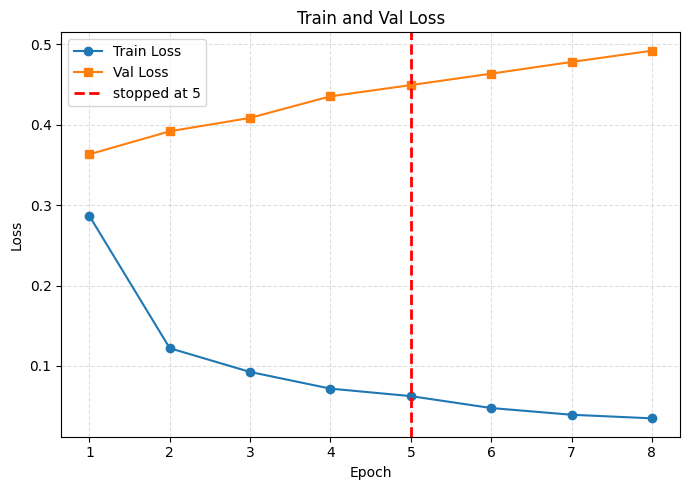

In [63]:
plt.figure(figsize=(7, 5))
plt.plot(e, tl, label="Train Loss", marker='o')
plt.plot(e, vl, label="Val Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train and Val Loss")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_loss.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

# Tampilkan di output cell
plt.show()

# Tutup plot (opsional di Kaggle untuk mencegah memory leak)
plt.close()

Grafik disimpan ke: chart_file/focal-loss-weight_train_val_accuracy.png


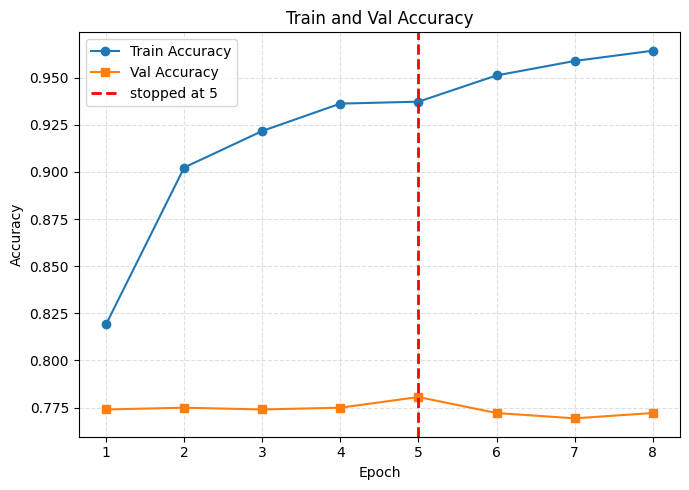

In [64]:
plt.figure(figsize=(7, 5))
plt.plot(e, ta, label="Train Accuracy", marker='o')
plt.plot(e, va, label="Val Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train and Val Accuracy")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_accuracy.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

# Tampilkan di output cell
plt.show()

# Tutup plot (opsional di Kaggle untuk mencegah memory leak)
plt.close()

Grafik disimpan ke: chart_file/focal-loss-weight_train_val_f1_macro.png


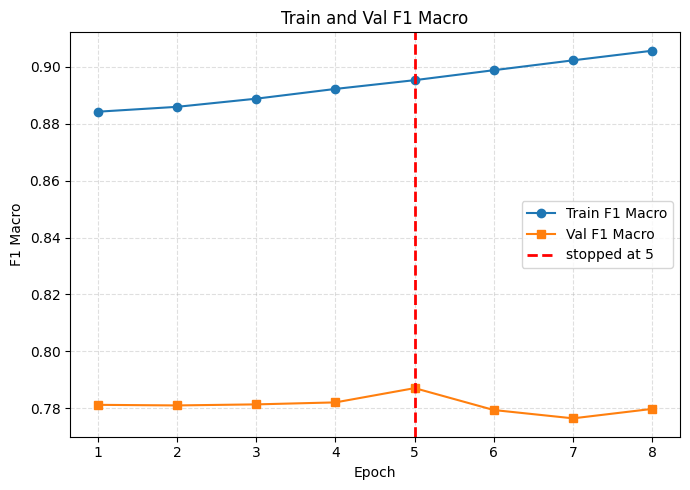

In [65]:
plt.figure(figsize=(7, 5))
plt.plot(e, tf, label="Train F1 Macro", marker='o')
plt.plot(e, vf, label="Val F1 Macro", marker='s')
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.title("Train and Val F1 Macro")
plt.axvline(x=len(e)-3, color='red', linestyle='--', linewidth=2, label=f'stopped at {len(e)-3}')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

# Simpan gambar
save_path = os.path.join(CHART_DIR, f"{name}_train_val_f1_macro.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")

plt.show()
plt.close()

In [66]:
# Buat instance baru dari arsitektur model Anda
# Pastikan base_model masih ada dari proses loading sebelumnya
model_terbaik_focalweight = EmotionClassifier(model, NUM_CLASSES, DROPOUT_RATE).to(device)

# Muat bobot yang sudah disimpan
model_terbaik_focalweight.load_state_dict(torch.load(best_model_path_focalweight))

# Set model ke mode evaluasi
model_terbaik_focalweight.eval()

print("MODEL FOCAL LOSS dengan WEIGHT terbaik berhasil dimuat.")

MODEL FOCAL LOSS dengan WEIGHT terbaik berhasil dimuat.


In [67]:
final_predictions = []
final_true_labels = []

# Matikan perhitungan gradien untuk evaluasi
with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Mengevaluasi MODEL FOCAL LOSS DENGAN WEIGHT terbaik"):
        input_ids, attention_mask, labels = batch
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        
        # Dapatkan output dari model terbaik
        outputs = model_terbaik_focalweight(input_ids, attention_mask)

        # Hitung loss untuk batch ini
        loss = criterion(outputs, labels)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        
        # Dapatkan prediksi kelas
        _, predicted = torch.max(outputs, 1)
        
        # Kumpulkan prediksi dan label asli
        final_predictions.extend(predicted.cpu().numpy())
        final_true_labels.extend(labels.cpu().numpy())

Mengevaluasi MODEL FOCAL LOSS DENGAN WEIGHT terbaik:   0%|          | 0/34 [00:00<?, ?it/s]

In [68]:
acc = accuracy_score(final_true_labels, final_predictions)
prec = precision_score(final_true_labels, final_predictions, average='macro')
rec = recall_score(final_true_labels, final_predictions, average='macro')
f1 = f1_score(final_true_labels, final_predictions, average='macro')

log_test("focal-loss-weight", loss, acc, f1)

print(f"acc: {acc}")
print(f"prec: {prec}")
print(f"rec: {rec}")
print(f"f1: {f1}")
print(f"loss: {loss}")

acc: 0.7890772128060264
prec: 0.7913831516452952
rec: 0.8063655615755074
f1: 0.79742800514156
loss: 0.552583634853363


--- Laporan Klasifikasi Model Terbaik ---
              precision    recall  f1-score   support

       Anger       0.80      0.85      0.83       170
        Fear       0.86      0.83      0.84       136
         Joy       0.82      0.78      0.80       192
        Love       0.73      0.85      0.79       114
     Neutral       0.76      0.70      0.73       300
         Sad       0.77      0.83      0.80       150

    accuracy                           0.79      1062
   macro avg       0.79      0.81      0.80      1062
weighted avg       0.79      0.79      0.79      1062


--- Confusion Matrix ---
Grafik disimpan ke: chart_file/focal-loss-weight_confusion_matrix.png


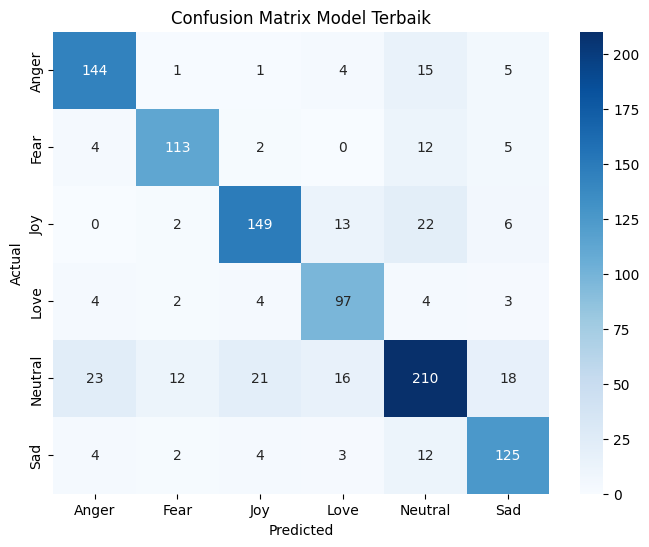

In [69]:
# Tampilkan Classification Report
print("--- Laporan Klasifikasi Model Terbaik ---")
report = classification_report(
    final_true_labels, 
    final_predictions, 
    target_names=class_names
)
print(report)

# Tampilkan Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(final_true_labels, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Model Terbaik')
save_path = os.path.join(CHART_DIR, f"{name}_confusion_matrix.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")
plt.show()
plt.close()

# Evaluasi Semua Skenario

In [70]:
path_skenario_1 = "log_file/cross-entropy_test.csv"
path_skenario_2 = "log_file/weighted-cross-entropy_test.csv"
path_skenario_3 = "log_file/focal-loss-gamma_test.csv"
path_skenario_4 = "log_file/focal-loss-weight_test.csv"



tel1, tea1, tef1 = read_metrics_test(path_skenario_1)
tel2, tea2, tef2 = read_metrics_test(path_skenario_2)
tel3, tea3, tef3 = read_metrics_test(path_skenario_3)
tel4, tea4, tef4 = read_metrics_test(path_skenario_4)
model_list = ["CE", "CWE", "FLG", "FLGW"]

Grafik disimpan ke: chart_file/loss.png


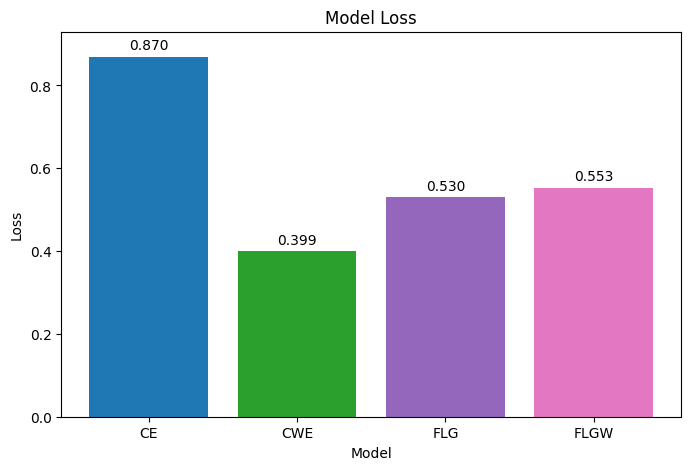

In [71]:
loss_list = [tel1, tel2, tel3, tel4]
loss_list = [x[0] for x in loss_list]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(model_list, loss_list, color=colors)
ax.set_ylim(0, min(1.0, max(loss_list) + 0.06))
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_title('Model Loss')
ax.set_xlabel('Model')
ax.set_ylabel('Loss')

save_path = os.path.join(CHART_DIR, "loss.png")
fig.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")
plt.show()
plt.close()

Grafik disimpan ke: chart_file/accuracy.png


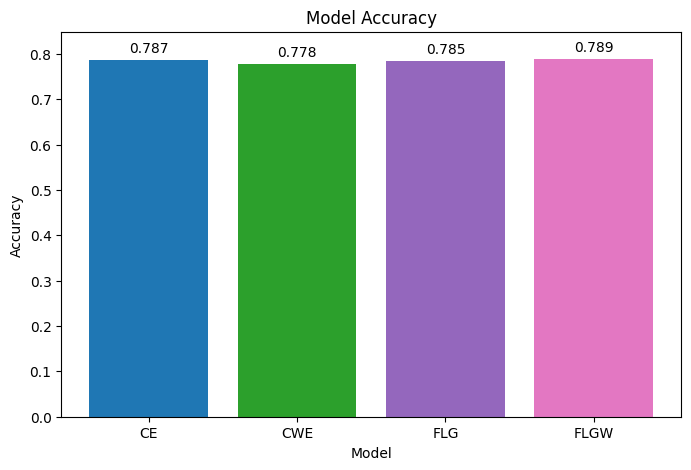

In [72]:
accuracy_list = [tea1, tea2, tea3, tea4]
accuracy_list = [x[0] for x in accuracy_list]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_list, accuracy_list, color=colors)
ax.set_ylim(0, min(1.0, max(accuracy_list) + 0.06))
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_title('Model Accuracy')
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')

save_path = os.path.join(CHART_DIR, "accuracy.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")
plt.show()
plt.close()

Grafik disimpan ke: chart_file/f1-score.png


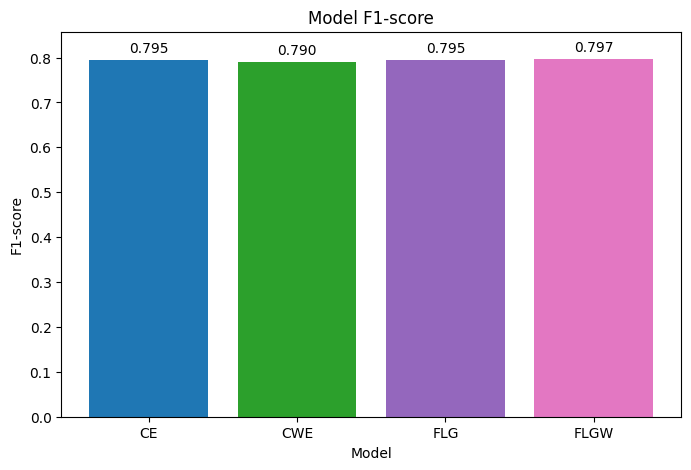

In [73]:
f1_list = [tef1, tef2, tef3, tef4]
f1_list = [x[0] for x in f1_list]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(model_list, f1_list, color=colors)
ax.set_ylim(0, min(1.0, max(f1_list) + 0.06))
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_title('Model F1-score')
ax.set_xlabel('Model')
ax.set_ylabel('F1-score')

save_path = os.path.join(CHART_DIR, "f1-score.png")
plt.savefig(save_path, dpi=300)
print(f"Grafik disimpan ke: {save_path}")
plt.show()
plt.close()